In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf, erfc

# Convolution of Gaussian and exponential

This case more closely resembles the propagation of information up and down the tree. Distribution at nodes tend to have a unimodal distribution describing where in time the node is sitting. This distribution is convolved with the length of the branch, which is positive and often has an exponential tail. 

We can, without loss of generality, parameterize this as follows:
$$f(x) = \begin{cases}
ae^{-ax}, & x \geq 0 \\
0, & x < 0
\end{cases}$$

$$g(x) = 
\frac{1}{2\pi}e^{-\frac{x^2}{2}} 
$$
In terms of parameters, what matters is the magnitude of $a$ compared to the width of the Gaussian ($\sigma=1$) and the discretization. 

While this convolution does not have a closed form expression, it can be expressed in terms of special functions:

$$\begin{split}
(f*g)(x) &= \frac{a}{\sqrt{2\pi}}\int_0^\infty ds e^{-as} e^{-\frac{(x-s)^2}{2}} \\
& = \frac{ae^{-\frac{x^2 - (x-a)^2}{2}}}{\sqrt{2\pi}}\int_0^\infty ds e^{-\frac{(s - x + a)^2}{2}} \\
& = \frac{ae^{\frac{-2xa + a^2}{2}}}{\sqrt{2\pi}} \int_{a-x}^\infty ds e^{-\frac{s^2}{2}} \\
& = \frac{ae^{\frac{-2xa + a^2}{2}}}{2} erfc((a-x)/\sqrt{2})
\end{split}
$$

In [12]:
def f_exp(x):
    """Exponential decay function: f(x) = a*e^(-ax) for x≥0, 0 for x<0"""
    return a_f * np.exp(-a_f * x) * (x >= 0)

def g_gauss(x):
    """Exponential decay function: g(x) = b*e^(-bx) for x≥0, 0 for x<0"""
    return np.exp(-x**2/2)/np.sqrt(2*np.pi)


In [31]:
def analytical_result(x):
    return 0.5*a_f*np.exp(-x*a_f + a_f**2/2)*erfc((a_f-x)/np.sqrt(2))

In [37]:
def convolve(f, g, x, s_grid):
    """Numerical convolution using discrete integration (Riemann sum)."""
    ds = s_grid[1] - s_grid[0]  # Grid spacing Δs
    return ds * np.sum(f(s_grid) * g(x - s_grid))

In [67]:
a_f = 0.5

# Integration grid for convolution (s variable) 
s_grid = np.linspace(-1, 20/a_f, 101)

# Evaluation points for output
xmin, xmax = -5,5 + 10/a_f
x_grid = np.linspace(xmin,xmax, 101)

# Compute numerical convolution
numerical_result = []
for x in x_grid:
    numerical_result.append(convolve(f_exp, g_gauss, x, s_grid))

numerical_result = np.array(numerical_result)

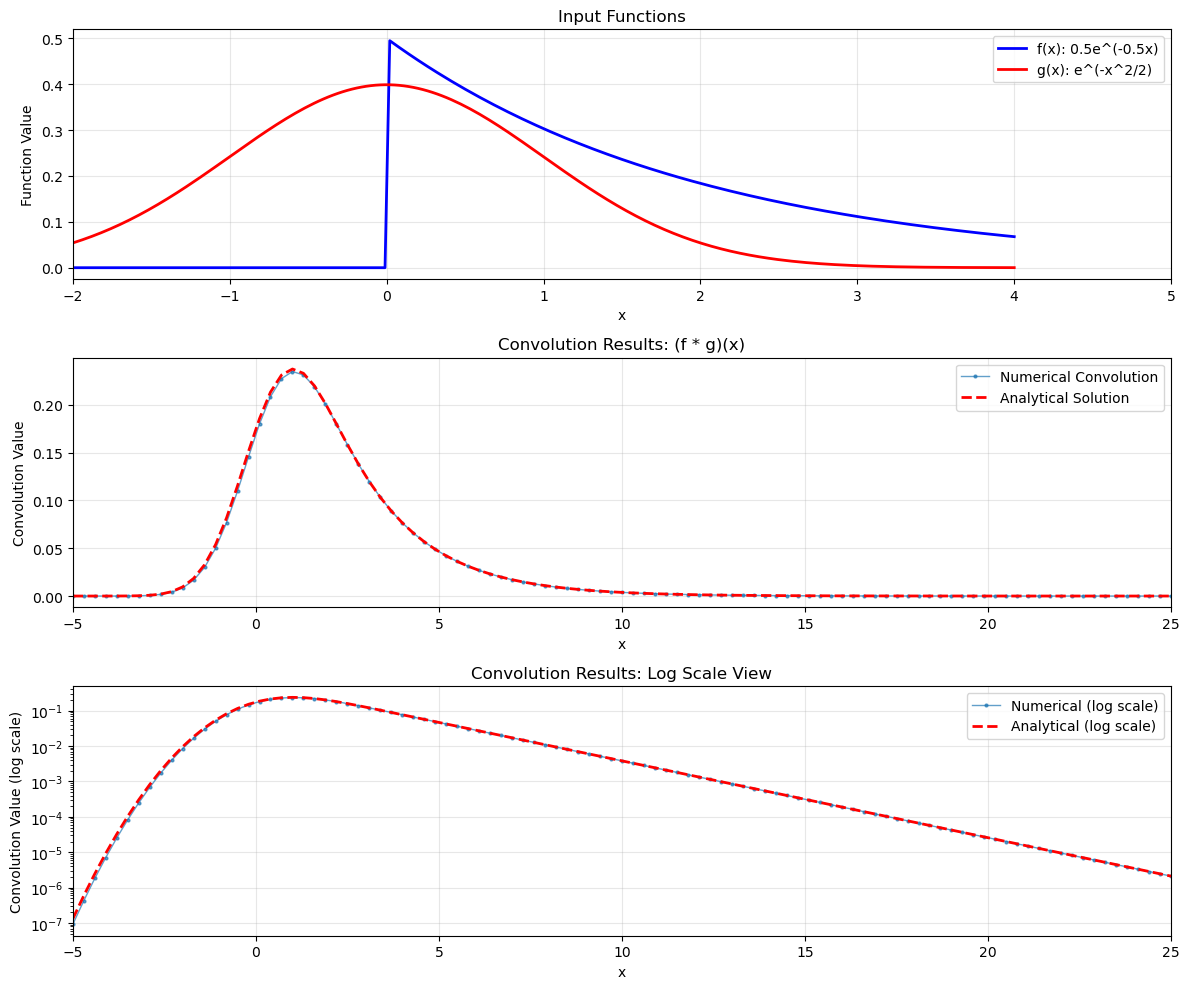

In [68]:
plt.figure(figsize=(12, 10))

# Plot input functions
plt.subplot(3, 1, 1)
x_input = np.linspace(-2, 4, 200)
plt.plot(x_input, f_exp(x_input), 'b-', label=f'f(x): {a_f}e^(-{a_f}x)', linewidth=2)
plt.plot(x_input, g_gauss(x_input), 'r-', label=f'g(x): e^(-x^2/2)', linewidth=2)
plt.xlabel('x')
plt.ylabel('Function Value')
plt.title('Input Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-2, 5)

# Plot convolution results
plt.subplot(3, 1, 2)
plt.plot(x_grid, numerical_result, 'o-', label='Numerical Convolution', 
         markersize=2, linewidth=1, alpha=0.7)
plt.plot(x_grid, analytical_result(x_grid), '--', label='Analytical Solution', 
         linewidth=2, color='red')
plt.xlabel('x')
plt.ylabel('Convolution Value')
plt.title('Convolution Results: (f * g)(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(xmin,xmax)

# Plot log scale for better visualization of exponential decay
plt.subplot(3, 1, 3)
plt.semilogy(x_grid, numerical_result, 
             'o-', label='Numerical (log scale)', markersize=2, linewidth=1, alpha=0.7)
plt.semilogy(x_grid, analytical_result(x_grid), 
             '--', label='Analytical (log scale)', linewidth=2, color='red')
plt.xlabel('x')
plt.ylabel('Convolution Value (log scale)')
plt.title('Convolution Results: Log Scale View')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(xmin,xmax)

plt.tight_layout()
plt.show()
